In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.drop('customerID',axis=1,inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
df.duplicated().sum()

np.int64(22)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [12]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

<Axes: >

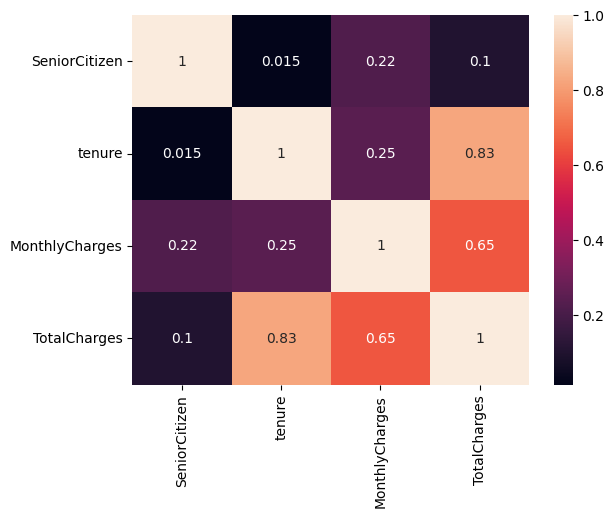

In [13]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
#

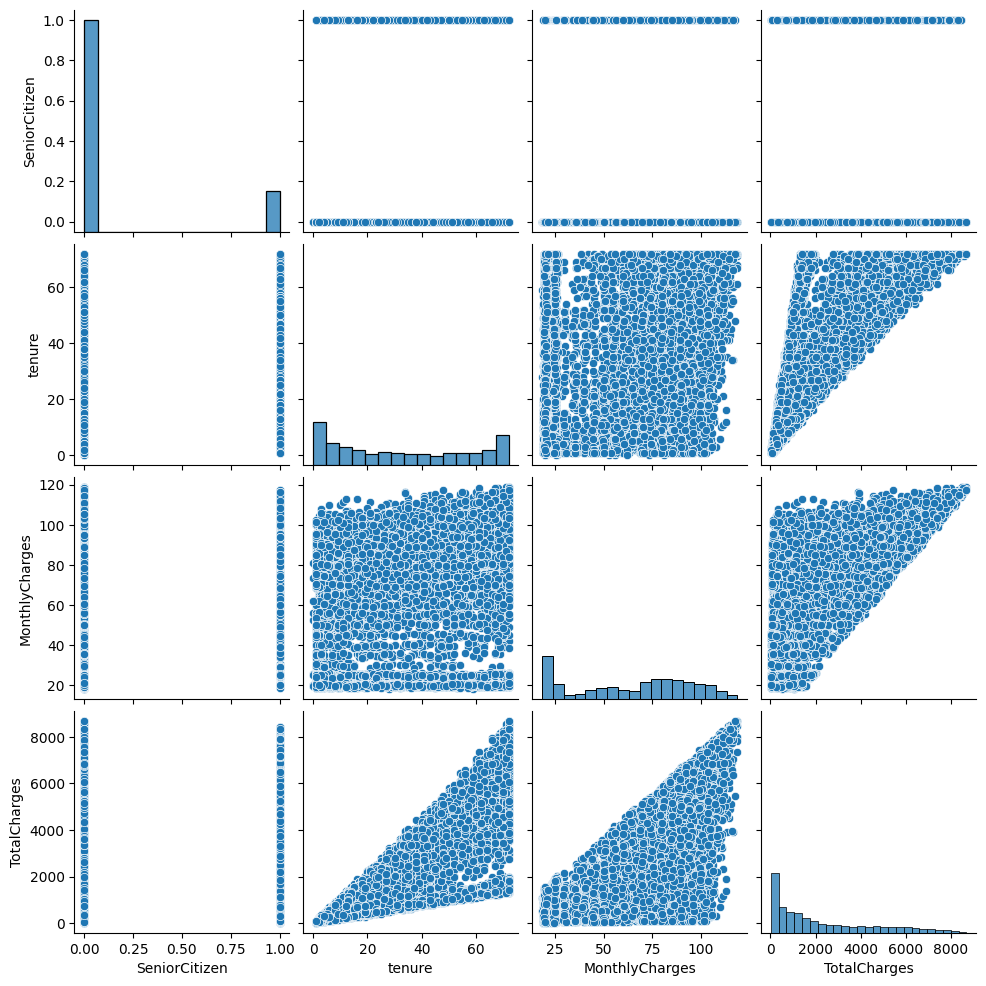

In [14]:
sns.pairplot(df)

<Axes: xlabel='Churn', ylabel='tenure'>

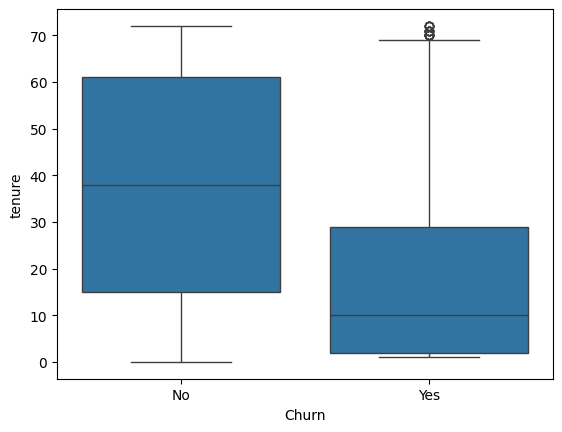

In [15]:
sns.boxplot(x='Churn',y='tenure',data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

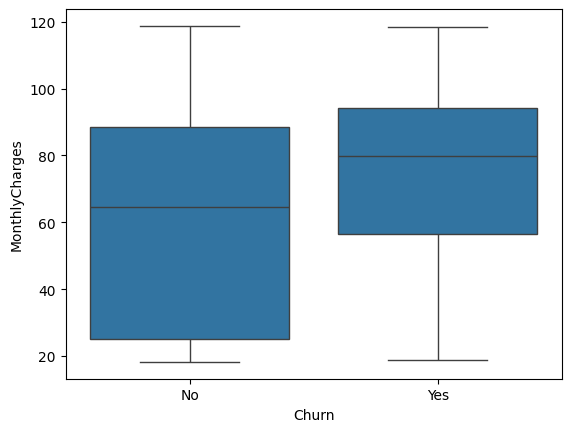

In [16]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)

<Axes: xlabel='Churn', ylabel='count'>

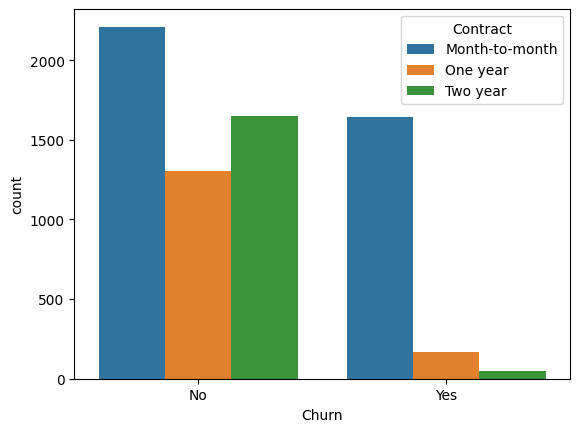

In [17]:
sns.countplot(x="Churn", hue="Contract", data=df)

In [18]:
nf = df.select_dtypes(exclude=['object'])
nf.head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [19]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df['TotalCharges'] = imputer.fit_transform(df[['TotalCharges']])
df['TotalCharges']

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [20]:
nf.skew()

,0
SeniorCitizen,1.829987
tenure,0.235542
MonthlyCharges,-0.224097
TotalCharges,0.958322


In [21]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

cat_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PowerTransformer,OrdinalEncoder,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [23]:
#skewned_cols
skew_col=['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
#othe_cols
#ordinal_col
ordinal_col=['PaymentMethod','Contract','InternetService','MultipleLines']
#other_col
other_col=['gender','Partner','Dependents','PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']

freature = skew_col + ordinal_col + other_col

# Convert 'Churn' column to numerical labels (0 and 1)
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

X=df[freature]
y=df['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
skew_pipeline = Pipeline(steps=[
    ('log_transform',PowerTransformer(method='yeo-johnson')),
    ('scaler',StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('encode',OrdinalEncoder())
])

other_pipeline = Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

Processer = ColumnTransformer([
    ('skew',skew_pipeline,skew_col),
    ('ordinal',ordinal_pipeline,ordinal_col),
    ('other',other_pipeline,other_col)
])

Processer

ColumnTransformer(transformers=[('skew',
                                 Pipeline(steps=[('log_transform',
                                                  PowerTransformer()),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('ordinal',
                                 Pipeline(steps=[('encode', OrdinalEncoder())]),
                                 ['PaymentMethod', 'Contract',
                                  'InternetService', 'MultipleLines']),
                                ('other',
                                 Pipeline(steps=[('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'PaperlessBilling'])])

In [60]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_Pipeline = Pipeline(steps=[
    ('Processer',Processer),
    ('lr',lr)
])
lr_Pipeline.fit(X_train,y_train)
y_pred = lr_Pipeline.predict(X_test)
y_pred_train = lr_Pipeline.predict(X_train)

print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_train,y_pred_train))
print(classification_report(y_test,y_pred))
print (confusion_matrix(y_test,y_pred))

0.7935943060498221
0.8101851851851852
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1053
           1       0.61      0.49      0.55       352

    accuracy                           0.79      1405
   macro avg       0.72      0.69      0.71      1405
weighted avg       0.78      0.79      0.79      1405

[[941 112]
 [178 174]]


In [57]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced',random_state=42)
rf_Pipeline = Pipeline(steps=[
    ('Processer',Processer),
    ('rf',rf)
])
rf_Pipeline.fit(X_train,y_train)
y_pred = rf_Pipeline.predict(X_test)
y_pred_train = rf_Pipeline.predict(X_train)

print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_train,y_pred_train))
print(classification_report(y_test,y_pred))
print (confusion_matrix(y_test,y_pred))



0.7829181494661922
0.9973290598290598
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1053
           1       0.59      0.45      0.51       352

    accuracy                           0.78      1405
   macro avg       0.71      0.67      0.69      1405
weighted avg       0.77      0.78      0.77      1405

[[941 112]
 [193 159]]


In [ ]:
from sklearn.model_selection import StratifiedKFold,GridSearchCV

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': [None, 'balanced', 'balanced_subsample']
}

rf_Pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    estimator=rf_Pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
y_pred_train = grid_search.predict(X_train)
accuracy_score(y_test,y_pred)
accuracy_score(y_train,y_pred_train)
print(classification_report(y_test,y_pred))
print (confusion_matrix(y_test,y_pred))

print(grid_search.best_params_)
print(grid_search.best_score_)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


In [62]:
import joblib as jb
jb.dump(lr_Pipeline,"Telco_Churn_LR.pkl")

['Telco_Churn_LR.pkl']